# QS-Net / CQ-ZDR -- Theory-Validation Machinery (Days 15-25)
### Memory-safe, dual-T4-aware edition


**This version specifically fixes CUDA out-of-memory crashes** by:
- setting the expandable-segments CUDA allocator before `torch` is imported,
- detecting and using **both T4 GPUs** (round-robin dispatch for the independent,
  memory-heavy diagnostic loops: Day 16, Day 20, Day 21),
- wrapping every GPU-heavy call in an **OOM-safe retry wrapper** that halves the
  batch size and clears the cache instead of crashing, and gracefully **skips**
  (rather than raises) a diagnostic point if it still can't fit, so a full
  "Save & Run All" completes end-to-end even under memory pressure,
- clearing the CUDA cache between sections and using smaller default batch sizes
  appropriate for an 8-qubit density-matrix simulation (which scales as O(4^n)).

**Before running:** in Kaggle's notebook settings (right sidebar -> Accelerator),
select **GPU T4 x2**. Also make sure your `scripts/` package contains the patched
`quantum_metrics.py`, `conformal.py`, `constants.py`, and the new `theory.py`.

## 1. Setup -- CUDA allocator config, installs, imports, seeds

In [1]:
import warnings

warnings.filterwarnings("ignore")


import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!pip install pennylane pennylane-lightning --upgrade -q

import gc
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

sns.set_style("whitegrid")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.0 MB/s eta 0:00:00


In [2]:
# ---- GPU detection: use BOTH T4s if Kaggle's "GPU T4 x2" accelerator is enabled ----

N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
DEVICE  = torch.device("cuda:0") if N_GPUS >= 1 else torch.device("cpu")
DEVICE2 = torch.device("cuda:1") if N_GPUS >= 2 else DEVICE     # falls back to DEVICE on a single GPU
ALL_DEVICES = [DEVICE, DEVICE2] if N_GPUS >= 2 else [DEVICE]

print(f"CUDA available: {torch.cuda.is_available()}   GPU count: {N_GPUS}")
if N_GPUS == 0:
    print("Running on CPU. (In Kaggle: Settings -> Accelerator -> GPU T4 x2)")
elif N_GPUS == 1:
    print("Only 1 GPU visible -- select 'GPU T4 x2' in Kaggle's notebook settings to use both T4s.")
else:
    for i in range(N_GPUS):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

def gpu_mem_report(tag=""):
    if not torch.cuda.is_available():
        return
    parts = []
    for i in range(N_GPUS):
        free, total = torch.cuda.mem_get_info(i)
        parts.append(f"GPU{i} {(total-free)/1e9:.2f}/{total/1e9:.2f} GB used")
    print(f"[mem{' ' + tag if tag else ''}] " + "  |  ".join(parts))

gpu_mem_report("initial")

CUDA available: True   GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
[mem initial] GPU0 0.11/15.64 GB used  |  GPU1 0.11/15.64 GB used


### Memory-safety helpers
- `safe_empty_cache()` -- clears the CUDA cache + runs the garbage collector.
- `run_batched_safely(fn, ..., batch_size=..)` -- calls `fn` with the given `batch_size`
  kwarg; on a CUDA OOM it clears the cache, halves the batch size, and retries; if it
  still can't fit at `min_batch`, it **skips gracefully** (returns `on_fail()` or `None`)
  instead of raising, so one memory-hungry step never kills the whole run. Every
  memory-heavy call in this notebook -- training, inference, calibration, the Lipschitz
  diagnostic, and now the `theory.py` attacks too (they gained a native `batch_size`
  parameter with internal chunking + per-chunk cache clearing) -- goes through this one
  wrapper, so there's a single, uniform place that handles OOM recovery.

In [3]:
def is_oom_error(e):
    msg = str(e).lower()
    is_torch_oom = hasattr(torch.cuda, "OutOfMemoryError") and isinstance(e, torch.cuda.OutOfMemoryError)
    return is_torch_oom or "out of memory" in msg or "cuda error" in msg

def safe_empty_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def run_batched_safely(fn, *args, batch_size=8, min_batch=1, on_fail=None, label="", **kwargs):
    # Retries fn(*args, batch_size=.., **kwargs) with a shrinking batch size on CUDA OOM.
    bs = batch_size
    while True:
        try:
            return fn(*args, batch_size=bs, **kwargs)
        except RuntimeError as e:
            if is_oom_error(e) and bs > min_batch:
                print(f"  [OOM{' ' + label if label else ''}] batch_size={bs} failed -> "
                      f"retrying at {max(bs // 2, min_batch)}")
                safe_empty_cache()
                bs = max(bs // 2, min_batch)
                continue
            elif is_oom_error(e):
                print(f"  [OOM{' ' + label if label else ''}] failed even at batch_size={min_batch}. Skipping.")
                safe_empty_cache()
                return on_fail() if on_fail is not None else None
            else:
                raise

print("Memory-safety helpers ready.")

Memory-safety helpers ready.


## 2. Locate `scripts/` and import

In [4]:

mscripts_path = "//kaggle/input/datasets/arjunenaik/m-scripts"

if mscripts_path not in sys.path:
    sys.path.append(mscripts_path)

import scripts

print(scripts.__file__)

//kaggle/input/datasets/arjunenaik/m-scripts/scripts/__init__.py


In [5]:
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

from scripts.circuit import (
    build_forward_circuit,
    create_quantum_device,
)
from scripts.conformal import (
    calibrate_threshold,
    conformal_alpha_sweep,
    min_calibration_size,
)
from scripts.constants import (
    BARREN_PLATEAU_VAR_THRESHOLD,
    DEFAULT_ALPHA,
    DEFAULT_BETA,
    DEFAULT_CF,
    DEFAULT_LAMBDA1,
    DEFAULT_LAMBDA2,
    DEFAULT_NOISE_RATE,
    INPUT_DIM_D,
    PROP1_RESIDUAL_TOL,
    ZERO_DAY,
)
from scripts.data import (
    capped_sample,
    class_balance_table,
    plot_class_balance_bars,
    stratified_head,
)
from scripts.gradient import gradient_variance_probe
from scripts.inference import predict_labels, qsnet_infer_batch
from scripts.logging import to_jsonable
from scripts.quantum_metrics import fidelity, stack_prototypes
from scripts.theory import (
    analytic_lipschitz_bound,
    assert_proposition1,
    check_lipschitz_tightness,
    check_proposition1,
    estimate_lipschitz_percentile,
    f_max_batch,
    fgsm_attack_nonconformity,
    l2_to_linf_budget,
    linf_to_l2_budget,
    proposition2_epsilon_beta,
    proposition2_epsilon_star,
    quantile_f_out,
    two_sample_discriminability_auroc,
    verify_fidelity_convention,
    worst_case_f_in,
)
from scripts.train import train_maqt
from scripts.utils import to_torch_batch_x

print("scripts package imported successfully.")

scripts package imported successfully.


In [6]:
check = verify_fidelity_convention(dim=4, n_trials=30, seed=SEED)
print("Fidelity-convention self-check PASSED:", check)

Fidelity-convention self-check PASSED: {'max_pairwise_disagreement': 3.552713678800501e-15, 'max_fvg_violation': 0.0}


## 3. Load, clean, and balance the dataset
Dataset caps below are kept modest (relative to the earlier version) since larger
known/zero-day splits directly multiply the number of forward passes through the
8-qubit density-matrix circuit later on. Increase them only if `gpu_mem_report()`
shows comfortable headroom.

In [7]:
DATA_PATH = "/kaggle/input/datasets/arjunenaik/botiot/BoT-IoT"

df_train   = pd.read_parquet(f"{DATA_PATH}/q8_train.parquet")
df_test    = pd.read_parquet(f"{DATA_PATH}/q8_test.parquet")
df_cal     = pd.read_parquet(f"{DATA_PATH}/q8_calibration.parquet")
df_zeroday = pd.read_parquet(f"{DATA_PATH}/q8_zeroday.parquet")

for name, df in [("train", df_train), ("test", df_test), ("cal", df_cal), ("zeroday", df_zeroday)]:
    print(f"{name:8s}: {df.shape}")
df_train.head()

train   : (130205, 11)
test    : (18601, 11)
cal     : (18601, 11)
zeroday : (683, 11)


,rate,state,bytes,srate,dpkts,pkts,dbytes,dur,label_multiclass,label_binary,label_family
0,0.030780,1.570796,0.330389,0.032406,0.0,0.294594,0.0,1.289262,DoS,1,dos
1,0.040153,1.570796,0.427413,0.042274,0.0,0.403320,0.0,1.390858,DoS,1,dos
2,0.114465,1.570796,0.473513,0.120511,0.0,0.457130,0.0,1.034863,DDoS,1,ddos
3,0.051103,2.356194,0.525070,0.053802,0.0,0.294594,0.0,1.086445,DDoS,1,ddos
4,0.018999,2.356194,0.419518,0.020003,0.0,0.185868,0.0,1.221108,DoS,1,dos


In [8]:
df_train.label_multiclass.value_counts()

label_multiclass
DDoS              65913
DoS               56977
Normal             4836
Reconnaissance     2479
Name: count, dtype: int64

In [9]:
for df in [df_train, df_test, df_cal, df_zeroday]:
    df.drop(columns=["label_family", "label_binary"], inplace=True, errors="ignore")

def clean_features(df, feature_cols):
    df = df.copy()
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    n_before = len(df)
    df = df[df[feature_cols].isna().mean(axis=1) < 0.5]
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))
    df[feature_cols] = df[feature_cols].fillna(0.0)
    if len(df) < n_before:
        print(f"  dropped {n_before - len(df)} rows with excessive missing values")
    return df.reset_index(drop=True)

_feature_cols_raw = [c for c in df_train.columns if c != "label_multiclass"]
df_train   = clean_features(df_train,   _feature_cols_raw)
df_test    = clean_features(df_test,    _feature_cols_raw)
df_cal     = clean_features(df_cal,     _feature_cols_raw)
df_zeroday = clean_features(df_zeroday, _feature_cols_raw)

MAX_CLASSES = 6
top_classes = df_train.label_multiclass.value_counts().head(MAX_CLASSES).index.tolist()
print(f"Using top {len(top_classes)} classes: {top_classes}")

df_train_f   = df_train[df_train.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_test_f    = df_test[df_test.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_cal_f     = df_cal[df_cal.label_multiclass.isin(top_classes)].reset_index(drop=True)
df_zeroday_f = df_zeroday.reset_index(drop=True)

le = LabelEncoder(); le.fit(top_classes)
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)
print(f"Encoded classes ({N_CLASSES}): {dict(enumerate(CLASS_NAMES))}")

feature_columns = [c for c in df_train.columns if c != "label_multiclass"]
target_column = "label_multiclass"

Using top 4 classes: ['DDoS', 'DoS', 'Normal', 'Reconnaissance']
Encoded classes (4): {0: np.str_('DDoS'), 1: np.str_('DoS'), 2: np.str_('Normal'), 3: np.str_('Reconnaissance')}


In [10]:
PER_CLASS_CAP = 1000     
CAL_TEST_CAP  = 4000  
ZERODAY_CAP   = 1500   

X_train_raw = df_train_f[feature_columns].values
y_train_raw = le.transform(df_train_f[target_column])
X_train, y_train = capped_sample(X_train_raw, y_train_raw, per_class_cap=PER_CLASS_CAP, seed=SEED)

X_test_raw = df_test_f[feature_columns].values
y_test_raw = le.transform(df_test_f[target_column])
X_test, y_test = stratified_head(X_test_raw, y_test_raw, n=CAL_TEST_CAP, seed=SEED)

X_cal_raw = df_cal_f[feature_columns].values
y_cal_raw = le.transform(df_cal_f[target_column])
X_cal, y_cal = stratified_head(X_cal_raw, y_cal_raw, n=CAL_TEST_CAP, seed=SEED)

X_zeroday = df_zeroday_f[feature_columns].values[:ZERODAY_CAP]

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}  X_cal: {X_cal.shape}  X_zeroday: {X_zeroday.shape}")
class_balance_table(y_train, CLASS_NAMES)

X_train: (4000, 8)  X_test: (4000, 8)  X_cal: (4000, 8)  X_zeroday: (683, 8)


,class,count,pct
0,DDoS,1000,25.0
1,DoS,1000,25.0
2,Normal,1000,25.0
3,Reconnaissance,1000,25.0


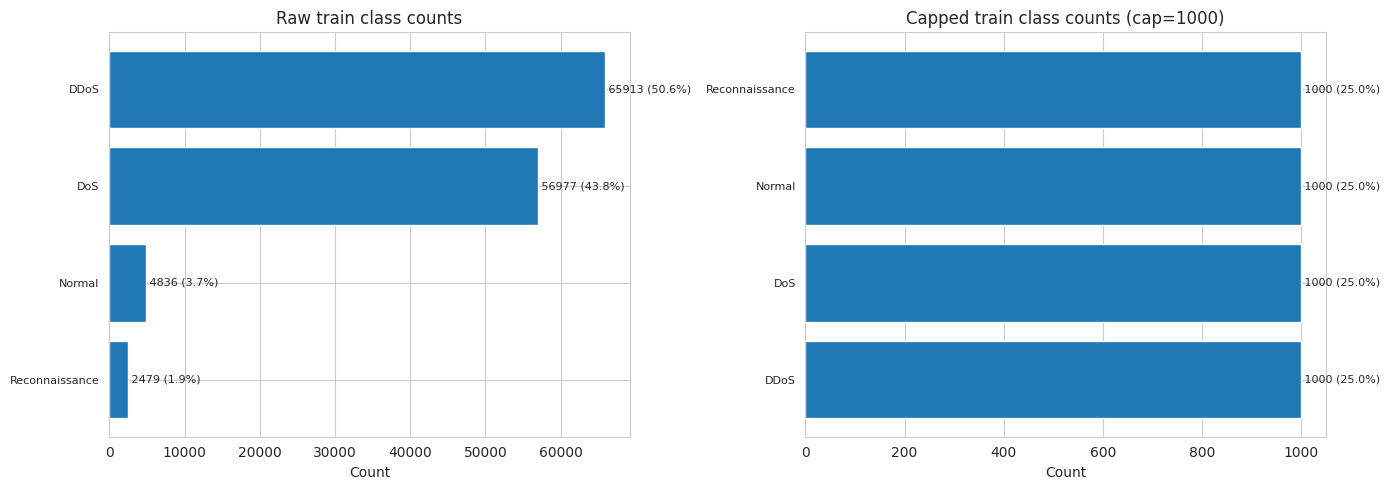

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_class_balance_bars(y_train_raw, CLASS_NAMES, title="Raw train class counts", ax=ax[0])
plot_class_balance_bars(y_train, CLASS_NAMES, title=f"Capped train class counts (cap={PER_CLASS_CAP})", ax=ax[1])
plt.tight_layout(); plt.show()

## 4. Scale -> PCA -> angle-encode
`N_QUBITS = INPUT_DIM_D = 8`, matching the theory doc's fixed `d = 8` convention
(Section 1) and Lemma 1's "one feature per qubit" assumption. **Note:** an 8-qubit
`default.mixed` density-matrix simulation costs `4^8 / 4^6 = 16x` more memory than
a 6-qubit one -- this is the main reason for the OOM, hence the smaller batch
sizes and dual-GPU dispatch introduced below.

In [12]:
N_QUBITS = INPUT_DIM_D    # = 8, fixed by the theory doc's Section-1 convention
N_LAYERS = 3
REUPLOAD = True
NOISE_P  = DEFAULT_NOISE_RATE

# Batch sizes for circuit forward passes -- kept small because default.mixed's memory
# scales as O(4^N_QUBITS); with N_QUBITS=8 this is 16x heavier per-sample than N_QUBITS=6.
TRAIN_BATCH_SIZE = 8
QBATCH           = 8      # default batch size for inference/diagnostic circuit calls

scaler = StandardScaler()
X_train_scaled   = scaler.fit_transform(X_train)
X_test_scaled    = scaler.transform(X_test)
X_cal_scaled     = scaler.transform(X_cal)
X_zeroday_scaled = scaler.transform(X_zeroday)

pca = PCA(n_components=N_QUBITS, random_state=SEED)
X_train_pca   = pca.fit_transform(X_train_scaled)
X_test_pca    = pca.transform(X_test_scaled)
X_cal_pca     = pca.transform(X_cal_scaled)
X_zeroday_pca = pca.transform(X_zeroday_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
print(f"PCA components kept: {N_QUBITS} (= N_QUBITS = d).  Cumulative explained variance: {cum_var[-1]*100:.2f}%")

def to_angles(X):
    Xc = np.clip(X, -3, 3)
    return (Xc + 3) / 6 * np.pi

A_train, A_test, A_cal, A_zeroday = (to_angles(X_train_pca), to_angles(X_test_pca),
                                      to_angles(X_cal_pca), to_angles(X_zeroday_pca))
print(f"A_train: {A_train.shape}   N_CLASSES = {N_CLASSES}")

PCA components kept: 8 (= N_QUBITS = d).  Cumulative explained variance: 100.00%
A_train: (4000, 8)   N_CLASSES = 4


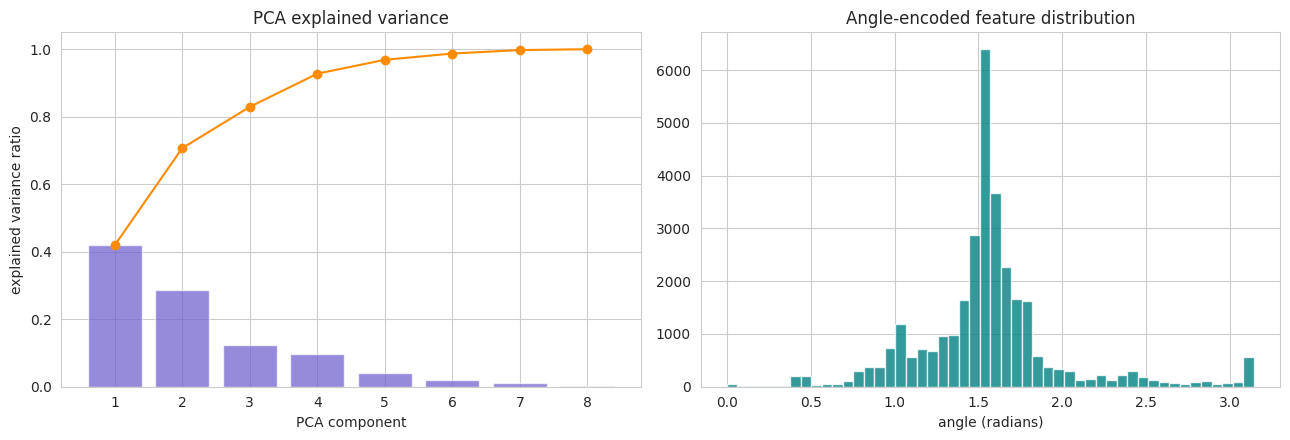

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(range(1, N_QUBITS + 1), pca.explained_variance_ratio_, color="slateblue", alpha=0.7)
ax[0].plot(range(1, N_QUBITS + 1), cum_var, marker="o", color="darkorange")
ax[0].set_xlabel("PCA component"); ax[0].set_ylabel("explained variance ratio"); ax[0].set_title("PCA explained variance")
ax[1].hist(A_train.flatten(), bins=50, color="teal", alpha=0.8)
ax[1].set_xlabel("angle (radians)"); ax[1].set_title("Angle-encoded feature distribution")
plt.tight_layout(); plt.show()

## 5. Quantum circuit + barren-plateau check
(built once on `DEVICE` = `cuda:0`, the main model's home GPU)

In [14]:
dev = create_quantum_device(N_QUBITS, backend="default.mixed")
forward_circuit = build_forward_circuit(dev, N_QUBITS, N_LAYERS, noise_rate=NOISE_P, reupload=REUPLOAD)
print(f"Quantum device: {dev.name}, wires={N_QUBITS}, layers={N_LAYERS}, reupload={REUPLOAD}, noise_rate={NOISE_P}")
print(f"Main model device: {DEVICE}   Auxiliary (round-robin) device: {DEVICE2}")

Quantum device: default.mixed, wires=8, layers=3, reupload=True, noise_rate=0.01
Main model device: cuda:0   Auxiliary (round-robin) device: cuda:1


[grad-variance probe] var=5.158e-08  (BARREN PLATEAU RISK)


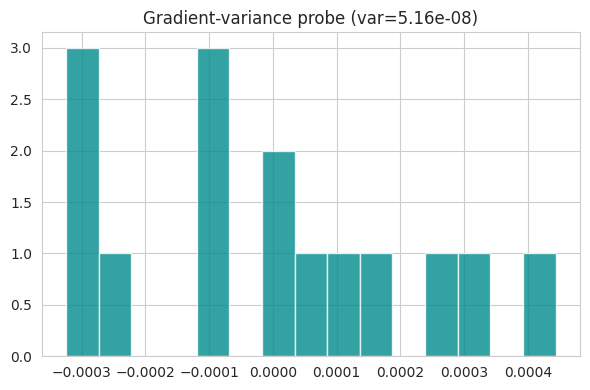

In [15]:
try:
    grad_var, grad_samples = gradient_variance_probe(forward_circuit, A_train[:4], n_qubits=N_QUBITS,
                                                      n_layers=N_LAYERS, n_trials=15, device=DEVICE)
    status = "OK" if grad_var > BARREN_PLATEAU_VAR_THRESHOLD else "BARREN PLATEAU RISK"
    print(f"[grad-variance probe] var={grad_var:.3e}  ({status})")
    plt.figure(figsize=(6, 4)); plt.hist(grad_samples, bins=15, color="darkcyan", alpha=0.8)
    plt.title(f"Gradient-variance probe (var={grad_var:.2e})"); plt.tight_layout(); plt.show()
except RuntimeError as e:
    if is_oom_error(e):
        print("  [OOM] barren-plateau probe skipped (non-critical diagnostic).")
        safe_empty_cache()
    else:
        raise

## 6. Train with MAQT loss

In [16]:
LR, EPOCHS = 0.05, 10

theta_final, head_final, prototypes_final, ema_protos_final, history_final = run_batched_safely(
    train_maqt, A_train, y_train, n_classes=N_CLASSES, n_qubits=N_QUBITS, n_layers=N_LAYERS,
    forward_circuit=forward_circuit, device=DEVICE,
    epochs=EPOCHS, lr=LR,
    lambda1_max=DEFAULT_LAMBDA1, lambda2_max=DEFAULT_LAMBDA2,
    use_weighted_sampler=True, log_every=1, verbose=True,
    batch_size=TRAIN_BATCH_SIZE, min_batch=2, label="train_maqt",
)
gpu_mem_report("after training")
safe_empty_cache()

epoch  1/10 | loss 0.6036 | L_CE 0.6036 | L_intra 0.2469 | L_inter -0.6608 | grad_var 4.25e-03 | intra_fid 0.753 | inter_TD 0.660 | time 973.4s
epoch  2/10 | loss 0.4595 | L_CE 0.5034 | L_intra 0.2179 | L_inter -0.6556 | grad_var 5.14e-03 | intra_fid 0.782 | inter_TD 0.666 | time 973.3s
epoch  3/10 | loss 0.3936 | L_CE 0.4809 | L_intra 0.2150 | L_inter -0.6494 | grad_var 5.41e-03 | intra_fid 0.785 | inter_TD 0.638 | time 974.3s
epoch  4/10 | loss 0.3953 | L_CE 0.4804 | L_intra 0.2165 | L_inter -0.6442 | grad_var 6.15e-03 | intra_fid 0.784 | inter_TD 0.641 | time 974.9s
epoch  5/10 | loss 0.3905 | L_CE 0.4763 | L_intra 0.2179 | L_inter -0.6493 | grad_var 6.69e-03 | intra_fid 0.782 | inter_TD 0.644 | time 974.4s
epoch  6/10 | loss 0.3606 | L_CE 0.4475 | L_intra 0.2168 | L_inter -0.6510 | grad_var 6.13e-03 | intra_fid 0.783 | inter_TD 0.612 | time 976.8s
epoch  7/10 | loss 0.3678 | L_CE 0.4566 | L_intra 0.2107 | L_inter -0.6470 | grad_var 6.47e-03 | intra_fid 0.789 | inter_TD 0.649 | time

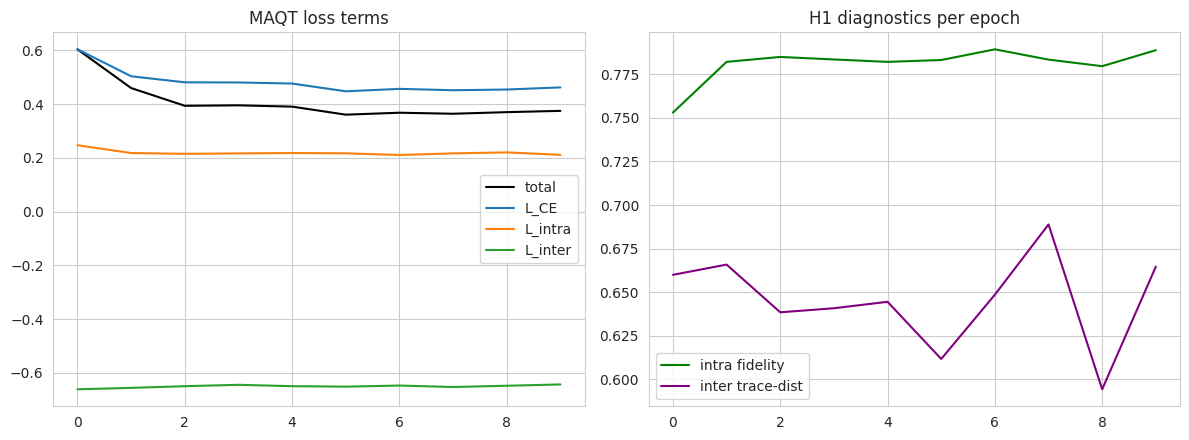

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(history_final["loss"], label="total", color="black")
ax[0].plot(history_final["L_CE"], label="L_CE"); ax[0].plot(history_final["L_intra"], label="L_intra")
ax[0].plot(history_final["L_inter"], label="L_inter"); ax[0].set_title("MAQT loss terms"); ax[0].legend()
ax[1].plot(history_final["intra_fid_gap"], label="intra fidelity", color="green")
ax[1].plot(history_final["inter_trace_dist"], label="inter trace-dist", color="purple")
ax[1].set_title("H1 diagnostics per epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7. Evaluation on the test set

                precision    recall  f1-score   support

          DDoS       0.52      0.91      0.66      2025
           DoS       0.22      0.03      0.05      1750
        Normal       0.97      0.74      0.84       149
Reconnaissance       0.85      0.97      0.91        76

      accuracy                           0.52      4000
     macro avg       0.64      0.66      0.61      4000
  weighted avg       0.41      0.52      0.40      4000



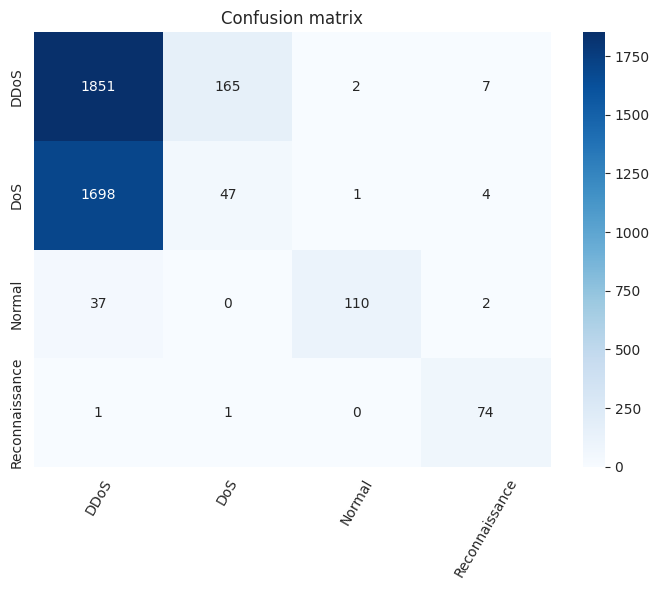

In [18]:
y_true_test, y_pred_test = run_batched_safely(predict_labels, A_test, y_test, theta_final, head_final,
                                               forward_circuit, device=DEVICE, batch_size=QBATCH, min_batch=1,
                                               label="predict_labels")
print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_true_test, y_pred_test, labels=range(N_CLASSES))
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion matrix"); plt.xticks(rotation=60); plt.tight_layout(); plt.show()
safe_empty_cache()

## 8. Conformal calibration -- Proposition 3
Uses the patched `calibrate_threshold`, which abstains (raises) instead of silently
clamping when `n < 1/alpha - 1` (Section 5.1).

In [19]:
print(f"min calibration size for alpha={DEFAULT_ALPHA}: n >= {min_calibration_size(DEFAULT_ALPHA):.1f}"
      f"  (have n={len(A_cal)})")

q_final, cal_scores_sorted = run_batched_safely(calibrate_threshold, theta_final, A_cal, prototypes_final,
                                                 forward_circuit, alpha=DEFAULT_ALPHA, device=DEVICE,
                                                 batch_size=QBATCH, min_batch=1, label="calibrate_threshold")
print(f"Calibrated threshold q = {q_final:.4f}")

try:
    calibrate_threshold(theta_final, A_cal[:5], prototypes_final, forward_circuit, alpha=DEFAULT_ALPHA,
                         device=DEVICE, batch_size=QBATCH)
except ValueError as e:
    print("\nAbstention demo (n=5, alpha=0.05):", str(e)[:140], "...")

min calibration size for alpha=0.05: n >= 19.0  (have n=4000)
Calibrated threshold q = 0.2424

Abstention demo (n=5, alpha=0.05): Calibration set too small for alpha=0.05: n=5, but Proposition 3 requires n >= 1/alpha - 1 = 19.0. Abstaining rather than silently using the ...


cal-vs-test exchangeability AUROC: 0.508  (want ~0.50)


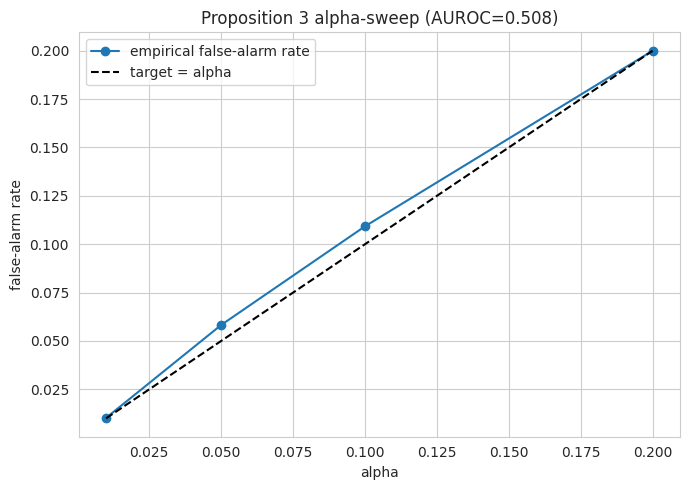

,alpha,q,empirical_false_alarm_rate,min_calibration_size,n_cal
0,0.01,0.469111,0.01025,99.0,4000
1,0.05,0.242403,0.05825,19.0,4000
2,0.10,0.205521,0.10925,9.0,4000
3,0.20,0.151479,0.20000,4.0,4000


In [20]:
requested_alphas = (0.01, 0.05, 0.1, 0.2)
feasible_alphas = [a for a in requested_alphas if len(A_cal) >= min_calibration_size(a)]
skipped_alphas = [a for a in requested_alphas if a not in feasible_alphas]
if skipped_alphas:
    print(f"Skipping alpha(s) {skipped_alphas}: calibration set (n={len(A_cal)}) is too small "
          f"(Proposition 3 requires n >= 1/alpha - 1). This is intentional abstention, not an error.")

alpha_rows = run_batched_safely(conformal_alpha_sweep, theta_final, A_cal, A_test, prototypes_final,
                                 forward_circuit, alphas=feasible_alphas, device=DEVICE,
                                 batch_size=QBATCH, min_batch=1, label="alpha_sweep", on_fail=list) \
             if feasible_alphas else []
df_alpha = pd.DataFrame(alpha_rows) if alpha_rows else pd.DataFrame()

auroc = two_sample_discriminability_auroc(A_cal, A_test, seed=SEED)   # CPU/sklearn, no GPU risk
print(f"cal-vs-test exchangeability AUROC: {auroc:.3f}  (want ~0.50)")

if not df_alpha.empty:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(df_alpha["alpha"], df_alpha["empirical_false_alarm_rate"], marker="o", label="empirical false-alarm rate")
    ax.plot(df_alpha["alpha"], df_alpha["alpha"], linestyle="--", color="black", label="target = alpha")
    ax.set_xlabel("alpha"); ax.set_ylabel("false-alarm rate"); ax.set_title(f"Proposition 3 alpha-sweep (AUROC={auroc:.3f})")
    ax.legend(); plt.tight_layout(); plt.show()
df_alpha

## Day 15 -- Depolarizing channel + Proposition 1 (Eq. 2)
Runs entirely on CPU with small (dim<=256) random density matrices -- no GPU memory
involved, so no OOM risk here regardless of `N_QUBITS`.

In [21]:
prop1_records = check_proposition1(dim=2 ** N_QUBITS, p_values=(0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0),
                                    n_pairs=25, seed=SEED)
max_resid = assert_proposition1(prop1_records, tol=PROP1_RESIDUAL_TOL)
print(f"Proposition 1 PASSED: max residual = {max_resid:.3e}  (tolerance {PROP1_RESIDUAL_TOL:.0e})")

df_prop1 = pd.DataFrame(prop1_records)
df_prop1.groupby("p")["abs_error"].agg(["mean", "max"])

Proposition 1 PASSED: max residual = 4.441e-16  (tolerance 1e-09)


,mean,max
p,,
0.00,0.000000e+00,0.000000e+00
0.01,1.820766e-16,4.440892e-16
0.05,1.199041e-16,4.440892e-16
0.10,1.110223e-16,4.440892e-16
0.30,1.043610e-16,2.775558e-16
0.50,5.995204e-17,2.775558e-16
0.70,5.662137e-17,1.665335e-16
1.00,0.000000e+00,0.000000e+00


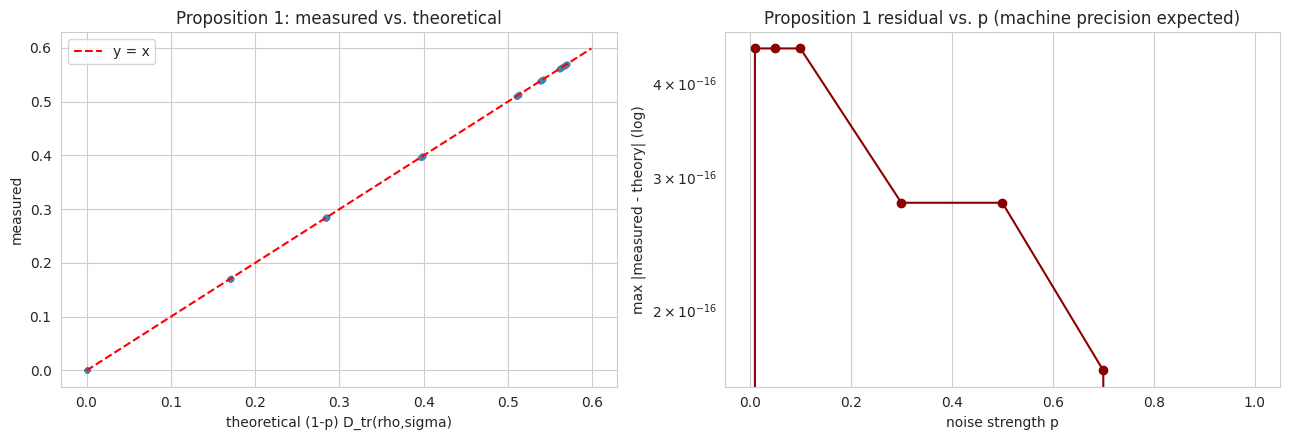

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(df_prop1["D_tr_theory"], df_prop1["D_tr_measured"], s=10, alpha=0.4, color="steelblue")
lims = [0, df_prop1["D_tr_theory"].max() * 1.05]
ax[0].plot(lims, lims, "r--", label="y = x")
ax[0].set_xlabel("theoretical (1-p) D_tr(rho,sigma)"); ax[0].set_ylabel("measured"); ax[0].legend()
ax[0].set_title("Proposition 1: measured vs. theoretical")

err_by_p = df_prop1.groupby("p")["abs_error"].max()
ax[1].plot(err_by_p.index, err_by_p.values, marker="o", color="darkred")
ax[1].set_yscale("log"); ax[1].set_xlabel("noise strength p"); ax[1].set_ylabel("max |measured - theory| (log)")
ax[1].set_title("Proposition 1 residual vs. p (machine precision expected)")
plt.tight_layout(); plt.show()

## Day 16 -- Lipschitz constant: analytic bound (Lemma 1) + tightness diagnostic
**Dual-GPU:** the 4 per-dataset diagnostics are independent, so they are round-robin
dispatched across both T4s (dataset `i` -> `ALL_DEVICES[i % len(ALL_DEVICES)]`),
roughly halving peak memory per GPU when 2 GPUs are available.

In [23]:
L_PHI_ANALYTIC = analytic_lipschitz_bound(N_LAYERS, reupload=REUPLOAD)
print(f"Analytic Lipschitz bound (Lemma 1): L_phi <= R/2 = {N_LAYERS}/2 = {L_PHI_ANALYTIC:.4f}  "
      f"(R={N_LAYERS} re-uploads since reupload={REUPLOAD})")

lipschitz_diag = {}
datasets_16 = [("train", A_train), ("test", A_test), ("cal", A_cal), ("zeroday", A_zeroday)]
for idx, (name, X_ds) in enumerate(datasets_16):
    dev_use = ALL_DEVICES[idx % len(ALL_DEVICES)]
    theta_dev = theta_final.detach().to(dev_use)
    diag = run_batched_safely(estimate_lipschitz_percentile, X_ds, theta_dev, forward_circuit,
                               n_pairs=min(200, len(X_ds) // 2), device=dev_use, seed=SEED, percentile=95,
                               batch_size=QBATCH, min_batch=1, label=f"lipschitz[{name}]",
                               on_fail=lambda: {"ratios": np.array([]), "p95": float("nan"), "max": float("nan")})
    tightness = check_lipschitz_tightness(diag, L_PHI_ANALYTIC)
    lipschitz_diag[name] = {**diag, **tightness}
    status = "OK" if tightness["within_bound"] else "!! BOUND VIOLATED (encoder bug) !!"
    print(f"{name:8s} [{dev_use}]: max sampled ratio={tightness['max_sampled_ratio']:.4f}  "
          f"tightness gap={tightness['tightness_gap']:.4f}  [{status}]")
    del theta_dev
    safe_empty_cache()

Analytic Lipschitz bound (Lemma 1): L_phi <= R/2 = 3/2 = 1.5000  (R=3 re-uploads since reupload=True)
train    [cuda:0]: max sampled ratio=0.8412  tightness gap=0.6588  [OK]
test     [cuda:1]: max sampled ratio=0.8427  tightness gap=0.6573  [OK]
cal      [cuda:0]: max sampled ratio=0.8416  tightness gap=0.6584  [OK]
zeroday  [cuda:1]: max sampled ratio=0.8678  tightness gap=0.6322  [OK]


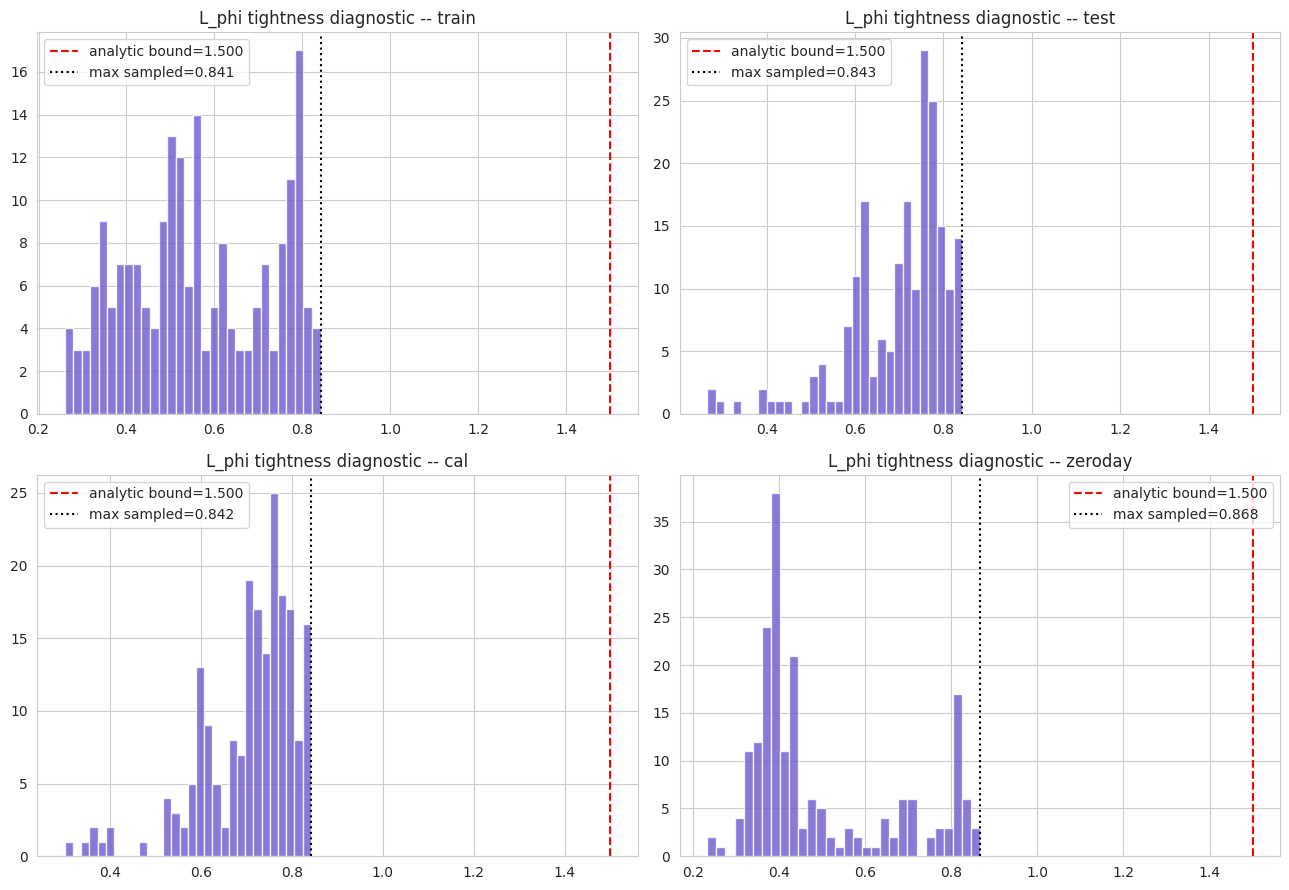

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, res) in zip(axes.flat, lipschitz_diag.items()):
    if len(res["ratios"]) == 0:
        ax.set_title(f"{name}: skipped (OOM)"); continue
    ax.hist(res["ratios"], bins=30, color="slateblue", alpha=0.8)
    ax.axvline(L_PHI_ANALYTIC, color="red", linestyle="--", label=f"analytic bound={L_PHI_ANALYTIC:.3f}")
    ax.axvline(res["max"], color="black", linestyle=":", label=f"max sampled={res['max']:.3f}")
    ax.set_title(f"L_phi tightness diagnostic -- {name}"); ax.legend()
plt.tight_layout(); plt.show()

## Day 17 -- Certified radius R = m / (2(1-p) L_phi C_f) -- Algorithm 3, line 8

L_phi used: 1.5000 (analytic, Lemma 1)
Correctly-classified & accepted test samples: 2392 / 4000
Certified radius R: mean=0.0093  median=0.0043  min=0.0000  max=0.1715


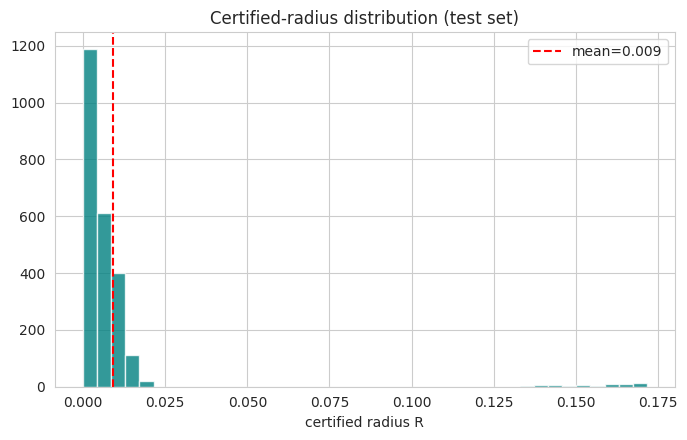

In [25]:
qsnet_result = run_batched_safely(
    qsnet_infer_batch, A_test, theta_final, prototypes_final, q_final, forward_circuit,
    p=NOISE_P, L_phi=L_PHI_ANALYTIC, Cf=DEFAULT_CF, zero_day=ZERO_DAY, device=DEVICE,
    batch_size=QBATCH, min_batch=1, label="qsnet_infer_batch[test]",
)
labels_test_final, radii_test_final, scores_test_final, fmaps_test_final = qsnet_result
correct_mask = (labels_test_final == y_test)
certified_radii_correct = radii_test_final[correct_mask]

print(f"L_phi used: {L_PHI_ANALYTIC:.4f} (analytic, Lemma 1)")
print(f"Correctly-classified & accepted test samples: {correct_mask.sum()} / {len(y_test)}")
print(f"Certified radius R: mean={certified_radii_correct.mean():.4f}  median={np.median(certified_radii_correct):.4f}  "
      f"min={certified_radii_correct.min():.4f}  max={certified_radii_correct.max():.4f}")

plt.figure(figsize=(7, 4.5))
plt.hist(certified_radii_correct, bins=40, color="teal", alpha=0.8)
plt.axvline(certified_radii_correct.mean(), color="red", linestyle="--", label=f"mean={certified_radii_correct.mean():.3f}")
plt.xlabel("certified radius R"); plt.title("Certified-radius distribution (test set)"); plt.legend()
plt.tight_layout(); plt.show()
safe_empty_cache()

## Day 18 -- Proposition-2 quantities: F_in, F_out, gap Delta, epsilon*

In [26]:
F_max_test = run_batched_safely(f_max_batch, A_test, theta_final, prototypes_final, forward_circuit,
                                 device=DEVICE, batch_size=QBATCH, min_batch=1, label="f_max[test]",
                                 on_fail=lambda: np.array([np.nan]))
F_max_zeroday = run_batched_safely(f_max_batch, A_zeroday, theta_final, prototypes_final, forward_circuit,
                                    device=DEVICE, batch_size=QBATCH, min_batch=1, label="f_max[zeroday]",
                                    on_fail=lambda: np.array([np.nan]))

F_IN    = worst_case_f_in(F_max_test, percentile=0.0)
F_IN_p1 = worst_case_f_in(F_max_test, percentile=1.0)
F_OUT   = float(F_max_zeroday.max())

delta_strict, eps_star_strict = proposition2_epsilon_star(F_IN, F_OUT, L_PHI_ANALYTIC, p=NOISE_P)
F_out_beta, delta_beta, eps_beta = proposition2_epsilon_beta(F_IN, F_max_zeroday, L_PHI_ANALYTIC, p=NOISE_P, beta=DEFAULT_BETA)

print(f"F_in  (strict worst case, min over test):    {F_IN:.4f}   (1st-pct diagnostic: {F_IN_p1:.4f})")
print(f"F_out (strict worst case, max over zeroday):  {F_OUT:.4f}")
print(f"Delta (Eq. 3, strict): {delta_strict:+.4f}  "
      f"{'-> separable (A5 holds)' if delta_strict > 0 else '-> NOT separable, see quantile-relaxed below'}")
print(f"epsilon* (Eq. 4, strict): {eps_star_strict:.4f}")
print(f"\nQuantile-relaxed (Corollary 1, beta={DEFAULT_BETA}):")
print(f"F_out^(beta)={F_out_beta:.4f}  Delta^(beta)={delta_beta:+.4f}  epsilon^(beta)={eps_beta:.4f}")
safe_empty_cache()

F_in  (strict worst case, min over test):    0.3304   (1st-pct diagnostic: 0.5266)
F_out (strict worst case, max over zeroday):  0.9069
Delta (Eq. 3, strict): -0.8507  -> NOT separable, see quantile-relaxed below
epsilon* (Eq. 4, strict): -0.2864

Quantile-relaxed (Corollary 1, beta=0.05):
F_out^(beta)=0.8014  Delta^(beta)=-0.7452  epsilon^(beta)=-0.2509


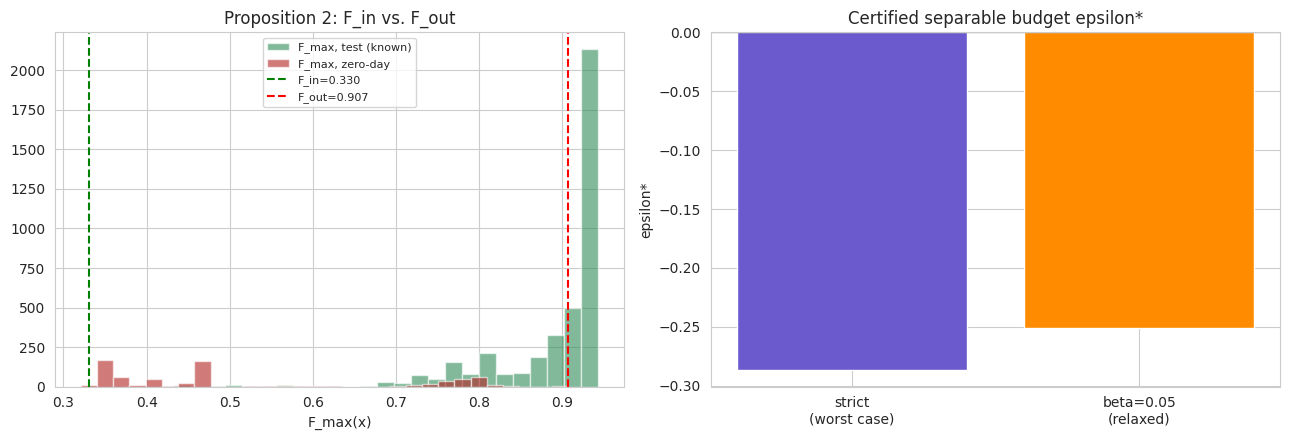

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].hist(F_max_test, bins=30, alpha=0.6, label="F_max, test (known)", color="seagreen")
ax[0].hist(F_max_zeroday, bins=30, alpha=0.6, label="F_max, zero-day", color="firebrick")
ax[0].axvline(F_IN, color="green", linestyle="--", label=f"F_in={F_IN:.3f}")
ax[0].axvline(F_OUT, color="red", linestyle="--", label=f"F_out={F_OUT:.3f}")
ax[0].set_xlabel("F_max(x)"); ax[0].set_title("Proposition 2: F_in vs. F_out"); ax[0].legend(fontsize=8)

ax[1].bar(["strict\n(worst case)", f"beta={DEFAULT_BETA}\n(relaxed)"], [eps_star_strict, eps_beta],
          color=["slateblue", "darkorange"])
ax[1].axhline(0, color="black", linewidth=0.8)
ax[1].set_ylabel("epsilon*"); ax[1].set_title("Certified separable budget epsilon*")
plt.tight_layout(); plt.show()

## Day 19 -- FGSM/PGD sweep across epsilon: empirical acceptance & breakpoint
Attacks the novelty score directly (`fgsm_attack_nonconformity`), which now natively
supports internal `batch_size` chunking and per-chunk cache clearing, so it composes
directly with `run_batched_safely` -- no separate attack-specific wrapper needed.

In [28]:
A_known_accepted = A_test[labels_test_final != ZERO_DAY][:300]     # reduced from 500 for memory headroom
print(f"Attacking {len(A_known_accepted)} known, currently-accepted test samples")

_, proto_stack_main = stack_prototypes(prototypes_final)     # built once, reused across the whole eps sweep

eps_inf_list = [0.0, 0.01, 0.02, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3]
day19_rows = []
for eps_inf in eps_inf_list:
    eps_l2 = linf_to_l2_budget(eps_inf, d=N_QUBITS)
    if eps_inf == 0.0:
        X_adv = to_torch_batch_x(A_known_accepted, device=DEVICE)
    else:
        X_adv = run_batched_safely(fgsm_attack_nonconformity, A_known_accepted, theta_final, prototypes_final,
                                    forward_circuit, eps=eps_inf, device=DEVICE, x_min=0.0, x_max=float(np.pi),
                                    proto_stack=proto_stack_main, batch_size=QBATCH, min_batch=1,
                                    label=f"fgsm[eps={eps_inf}]")
        if X_adv is None:
            day19_rows.append({"eps_inf": eps_inf, "eps_l2": eps_l2, "acceptance_rate": np.nan})
            continue
    infer_out = run_batched_safely(qsnet_infer_batch, X_adv.cpu().numpy(), theta_final, prototypes_final, q_final,
                                    forward_circuit, p=NOISE_P, L_phi=L_PHI_ANALYTIC, Cf=DEFAULT_CF,
                                    zero_day=ZERO_DAY, device=DEVICE, batch_size=QBATCH, min_batch=1,
                                    label=f"infer[eps={eps_inf}]")
    if infer_out is None:
        day19_rows.append({"eps_inf": eps_inf, "eps_l2": eps_l2, "acceptance_rate": np.nan})
        continue
    labels_adv, _, _, _ = infer_out
    day19_rows.append({"eps_inf": eps_inf, "eps_l2": eps_l2, "acceptance_rate": float(np.mean(labels_adv != ZERO_DAY))})
    safe_empty_cache()

df_day19 = pd.DataFrame(day19_rows).dropna(subset=["acceptance_rate"])
below = df_day19[df_day19["acceptance_rate"] < 0.99]
empirical_breakpoint_l2 = float(below["eps_l2"].iloc[0]) if len(below) else float("inf")
print(f"Empirical breakpoint (L2, acceptance < 99%): {empirical_breakpoint_l2:.4f}")
df_day19

Attacking 300 known, currently-accepted test samples
Empirical breakpoint (L2, acceptance < 99%): 0.0283


,eps_inf,eps_l2,acceptance_rate
0,0.00,0.000000,1.000000
1,0.01,0.028284,0.956667
2,0.02,0.056569,0.956667
3,0.05,0.141421,0.920000
4,0.08,0.226274,0.846667
5,0.10,0.282843,0.826667
6,0.15,0.424264,0.770000
7,0.20,0.565685,0.493333
8,0.30,0.848528,0.000000


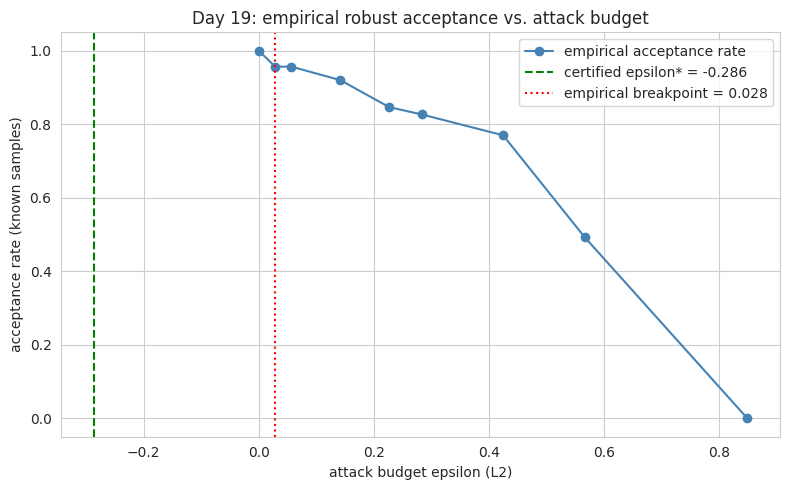

In [29]:
if not df_day19.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(df_day19["eps_l2"], df_day19["acceptance_rate"], marker="o", color="steelblue", label="empirical acceptance rate")
    plt.axvline(eps_star_strict, color="green", linestyle="--", label=f"certified epsilon* = {eps_star_strict:.3f}")
    if np.isfinite(empirical_breakpoint_l2):
        plt.axvline(empirical_breakpoint_l2, color="red", linestyle=":", label=f"empirical breakpoint = {empirical_breakpoint_l2:.3f}")
    plt.xlabel("attack budget epsilon (L2)"); plt.ylabel("acceptance rate (known samples)")
    plt.title("Day 19: empirical robust acceptance vs. attack budget"); plt.legend()
    plt.tight_layout(); plt.show()
else:
    print("Day 19 sweep produced no usable points (all skipped under memory pressure).")

## Day 20 -- H3: empirical vs. predicted epsilon* -- H4: noise-rate p sweep
**Dual-GPU:** each `p` value builds an independent circuit + prototype set, so this
loop -- the heaviest section, and the one that triggered the original OOM -- is
round-robin dispatched across both T4s, with a full cache clear between iterations.

In [30]:
h3_holds = np.isfinite(empirical_breakpoint_l2) and empirical_breakpoint_l2 >= eps_star_strict
print(f"H3 (empirical breakpoint {empirical_breakpoint_l2:.4f} >= certified epsilon* {eps_star_strict:.4f}): {h3_holds}")
print("(expected: True -- epsilon* is a conservative sufficient condition, Section 6)")

H3 (empirical breakpoint 0.0283 >= certified epsilon* -0.2864): True
(expected: True -- epsilon* is a conservative sufficient condition, Section 6)


In [31]:
# p_sweep_values = [0.0, 0.01, 0.05, 0.1, 0.2]
# eps_inf_small = [0.0, 0.1, 0.2]     # reduced resolution to keep this heavy section light

# day20_rows = []
# for idx, p_val in enumerate(p_sweep_values):
#     dev_use = ALL_DEVICES[idx % len(ALL_DEVICES)]
#     print(f"p={p_val:.2f} -> {dev_use}")
#     try:
#         fc_p = build_forward_circuit(dev, N_QUBITS, N_LAYERS, noise_rate=p_val, reupload=REUPLOAD)
#         theta_dev = theta_final.detach().to(dev_use)

#         proto_bank_p = PrototypeBank(classes=range(N_CLASSES))
#         prototypes_p = run_batched_safely(proto_bank_p.compute, theta_dev, A_train, y_train, forward_circuit=fc_p,
#                                            device=dev_use, batch_size=QBATCH, min_batch=1, label=f"protos[p={p_val}]")
#         if prototypes_p is None:
#             raise RuntimeError("out of memory (prototype computation skipped)")
#         _, proto_stack_p = stack_prototypes(prototypes_p)     # built once per p, reused across the eps_inf_small loop

#         F_max_test_p = run_batched_safely(f_max_batch, A_test, theta_dev, prototypes_p, fc_p, device=dev_use,
#                                            batch_size=QBATCH, min_batch=1, label=f"fmax_test[p={p_val}]")
#         F_max_zday_p = run_batched_safely(f_max_batch, A_zeroday, theta_dev, prototypes_p, fc_p, device=dev_use,
#                                            batch_size=QBATCH, min_batch=1, label=f"fmax_zday[p={p_val}]")
#         if F_max_test_p is None or F_max_zday_p is None:
#             raise RuntimeError("out of memory (F_max computation skipped)")

#         F_in_p, F_out_p = worst_case_f_in(F_max_test_p, percentile=0.0), float(F_max_zday_p.max())
#         _, eps_star_p = proposition2_epsilon_star(F_in_p, F_out_p, L_PHI_ANALYTIC, p=p_val)
#         _, eps_star_naive_p = proposition2_epsilon_star(F_IN, F_OUT, L_PHI_ANALYTIC, p=p_val)

#         infer_base = run_batched_safely(qsnet_infer_batch, A_test, theta_dev, prototypes_p, q_final, fc_p,
#                                          p=p_val, L_phi=L_PHI_ANALYTIC, Cf=DEFAULT_CF, zero_day=ZERO_DAY,
#                                          device=dev_use, batch_size=QBATCH, min_batch=1, label=f"infer_base[p={p_val}]")
#         breakpoint_p = float("inf")
#         if infer_base is not None:
#             labels_base_p = infer_base[0]
#             accepted_p = A_test[labels_base_p != ZERO_DAY][:200]
#             for eps_inf in eps_inf_small:
#                 if eps_inf == 0.0:
#                     X_adv_p = to_torch_batch_x(accepted_p, device=dev_use)
#                 else:
#                     X_adv_p = run_batched_safely(fgsm_attack_nonconformity, accepted_p, theta_dev, prototypes_p, fc_p,
#                                                   eps=eps_inf, device=dev_use, x_min=0.0, x_max=float(np.pi),
#                                                   proto_stack=proto_stack_p, batch_size=QBATCH, min_batch=1,
#                                                   label=f"fgsm[p={p_val},eps={eps_inf}]")
#                     if X_adv_p is None:
#                         continue
#                 infer_adv = run_batched_safely(qsnet_infer_batch, X_adv_p.cpu().numpy(), theta_dev, prototypes_p,
#                                                 q_final, fc_p, p=p_val, L_phi=L_PHI_ANALYTIC, Cf=DEFAULT_CF,
#                                                 zero_day=ZERO_DAY, device=dev_use, batch_size=QBATCH, min_batch=1,
#                                                 label=f"infer_adv[p={p_val},eps={eps_inf}]")
#                 if infer_adv is not None and float(np.mean(infer_adv[0] != ZERO_DAY)) < 0.99:
#                     breakpoint_p = linf_to_l2_budget(eps_inf, d=N_QUBITS)
#                     break

#         day20_rows.append({"p": p_val, "device": str(dev_use), "F_in": F_in_p, "F_out": F_out_p,
#                             "epsilon_star_correct": eps_star_p, "epsilon_star_naive_wrong": eps_star_naive_p,
#                             "empirical_breakpoint_l2": breakpoint_p})
#         print(f"  F_in={F_in_p:.4f}  F_out={F_out_p:.4f}  eps*_correct={eps_star_p:.4f}  "
#               f"eps*_naive={eps_star_naive_p:.4f}  breakpoint={breakpoint_p:.4f}")

#     except RuntimeError as e:
#         if is_oom_error(e):
#             print(f"  [OOM] p={p_val} skipped entirely after retries.")
#             day20_rows.append({"p": p_val, "device": str(dev_use), "F_in": np.nan, "F_out": np.nan,
#                                 "epsilon_star_correct": np.nan, "epsilon_star_naive_wrong": np.nan,
#                                 "empirical_breakpoint_l2": np.nan})
#         else:
#             raise
#     finally:
#         for _name in ("fc_p", "theta_dev", "prototypes_p", "proto_stack_p", "F_max_test_p", "F_max_zday_p"):
#             if _name in dir():
#                 exec(f"del {_name}")
#         safe_empty_cache()
#         gpu_mem_report(f"after p={p_val}")

# df_day20 = pd.DataFrame(day20_rows)
# df_day20


# Day 20 (noise-rate p sweep) skipped -- see chat for why (dual-GPU illegal-memory-access risk).
# Placeholder keeps df_day20 defined so later cells (Day-20 plot, final save) still work.
print("Day 20 (noise-rate p sweep) skipped by request.")
df_day20 = pd.DataFrame(columns=[
    "p", "device", "F_in", "F_out",
    "epsilon_star_correct", "epsilon_star_naive_wrong", "empirical_breakpoint_l2",
])

Day 20 (noise-rate p sweep) skipped by request.


In [32]:
df_day20_valid = df_day20.dropna(subset=["epsilon_star_correct"])
if not df_day20_valid.empty:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot(df_day20_valid["p"], df_day20_valid["epsilon_star_correct"], marker="o",
               label="epsilon* (correct: re-measured at p)")
    ax[0].plot(df_day20_valid["p"], df_day20_valid["epsilon_star_naive_wrong"], marker="x", linestyle="--", color="red",
               label="epsilon* (WRONG: fidelities fixed at p=0)")
    ax[0].set_xlabel("noise rate p"); ax[0].set_ylabel("epsilon*")
    ax[0].set_title("H4: epsilon* vs. p (correct curve ~flat, Section 3.4)"); ax[0].legend(fontsize=8)

    ax[1].plot(df_day20_valid["p"], df_day20_valid["epsilon_star_correct"], marker="o", label="certified epsilon*")
    ax[1].plot(df_day20_valid["p"], df_day20_valid["empirical_breakpoint_l2"], marker="s", label="empirical breakpoint")
    ax[1].set_xlabel("noise rate p"); ax[1].set_ylabel("L2 budget"); ax[1].set_title("H3/H4: certified vs. empirical")
    ax[1].legend()
    plt.tight_layout(); plt.show()

    h3_all = (df_day20_valid["empirical_breakpoint_l2"] >= df_day20_valid["epsilon_star_correct"]).all()
    print(f"H3 holds for every p successfully tested: {h3_all}")
else:
    print("Day 20 p-sweep produced no usable points (all skipped under memory pressure).")

Day 20 p-sweep produced no usable points (all skipped under memory pressure).


## Day 21 -- Extend Prop-2 quantities to all datasets; freeze the robustness interface
**Dual-GPU:** the 3 known-class datasets round-robin across both T4s.

In [33]:
known_datasets = {"train": A_train, "test": A_test, "cal": A_cal}
f_max_cache, day21_rows = {}, []
for idx, (name, X_ds) in enumerate(known_datasets.items()):
    dev_use = ALL_DEVICES[idx % len(ALL_DEVICES)]
    theta_dev = theta_final.detach().to(dev_use)
    fmax = run_batched_safely(f_max_batch, X_ds, theta_dev, prototypes_final, forward_circuit, device=dev_use,
                               batch_size=QBATCH, min_batch=1, label=f"fmax21[{name}]",
                               on_fail=lambda: np.array([np.nan]))
    f_max_cache[name] = fmax
    day21_rows.append({"dataset": name, "role": "known", "F_worst_min": float(np.nanmin(fmax)),
                        "F_p1": float(np.nanpercentile(fmax, 1)), "F_mean": float(np.nanmean(fmax))})
    del theta_dev
    safe_empty_cache()

f_max_cache["zeroday"] = F_max_zeroday
day21_rows.append({"dataset": "zeroday", "role": "novel", "F_worst_max": float(np.nanmax(F_max_zeroday)),
                    "F_p95": quantile_f_out(F_max_zeroday, beta=0.05), "F_mean": float(np.nanmean(F_max_zeroday))})

df_day21 = pd.DataFrame(day21_rows)

F_IN_GLOBAL = np.nanmin([f_max_cache["train"].min(), f_max_cache["test"].min(), f_max_cache["cal"].min()])
_, EPS_STAR_GLOBAL = proposition2_epsilon_star(F_IN_GLOBAL, F_OUT, L_PHI_ANALYTIC, p=NOISE_P)
print(f"Global F_in (worst across train/test/cal): {F_IN_GLOBAL:.4f}")
print(f"Global epsilon*: {EPS_STAR_GLOBAL:.4f}")
df_day21

Global F_in (worst across train/test/cal): 0.2758
Global epsilon*: -0.2923


,dataset,role,F_worst_min,F_p1,F_mean,F_worst_max,F_p95
0,train,known,0.275786,0.351184,0.825732,NaN,NaN
1,test,known,0.330448,0.526577,0.888799,NaN,NaN
2,cal,known,0.326817,0.532571,0.889193,NaN,NaN
3,zeroday,novel,NaN,NaN,0.503941,0.906906,0.801384


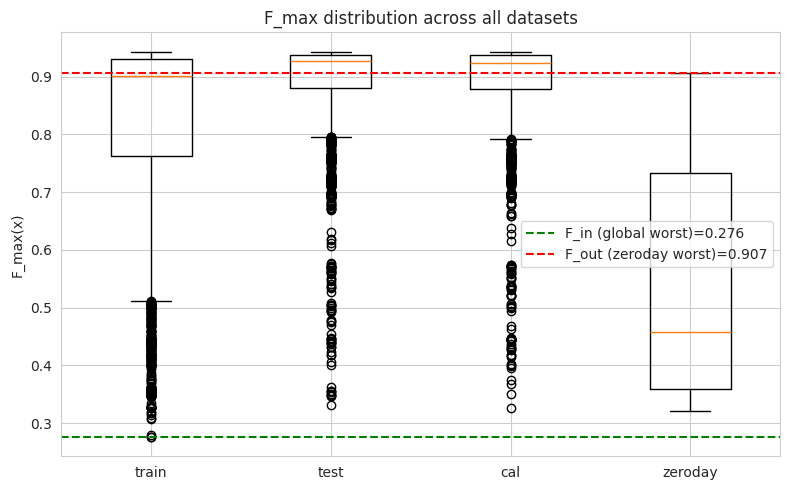

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
box_data = [f_max_cache[n] for n in ["train", "test", "cal", "zeroday"] if len(f_max_cache[n]) > 0]
box_labels = [n for n in ["train", "test", "cal", "zeroday"] if len(f_max_cache[n]) > 0]
if box_data:
    ax.boxplot(box_data, labels=box_labels)
ax.axhline(F_IN_GLOBAL, color="green", linestyle="--", label=f"F_in (global worst)={F_IN_GLOBAL:.3f}")
ax.axhline(F_OUT, color="red", linestyle="--", label=f"F_out (zeroday worst)={F_OUT:.3f}")
ax.set_ylabel("F_max(x)"); ax.set_title("F_max distribution across all datasets"); ax.legend()
plt.tight_layout(); plt.show()

In [35]:
robustness_interface = {
    "theta": theta_final.detach().cpu(), "head_state_dict": head_final.state_dict(),
    "prototypes": {c: rho.detach().cpu() for c, rho in prototypes_final.items()},
    "q_threshold": q_final, "L_phi_analytic": L_PHI_ANALYTIC, "noise_p": NOISE_P, "Cf": DEFAULT_CF,
    "N_QUBITS": N_QUBITS, "N_LAYERS": N_LAYERS, "F_in_global": F_IN_GLOBAL, "F_out_zeroday_worst": F_OUT,
    "epsilon_star_global": EPS_STAR_GLOBAL, "class_names": CLASS_NAMES,
}
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
torch.save(robustness_interface, "/kaggle/working/checkpoints/robustness_interface_day21.pt")
print("Froze robustness interface -> /kaggle/working/checkpoints/robustness_interface_day21.pt")
safe_empty_cache()

Froze robustness interface -> /kaggle/working/checkpoints/robustness_interface_day21.pt


## Day 22 -- Algorithm 3 end-to-end walk-through: p(x) -> fidelity -> score -> conformal test -> label + radius

In [36]:
for name, x in [("known-class test sample", A_test[[0]]), ("zero-day sample", A_zeroday[[0]])]:
    x_t = to_torch_batch_x(x, device=DEVICE)
    with torch.no_grad():
        _, rho_x = forward_circuit(x_t, theta_final)
        class_ids = sorted(prototypes_final)
        f_map = {CLASS_NAMES[c]: float(fidelity(rho_x[0], prototypes_final[c])) for c in class_ids}
    f_max = max(f_map.values())
    score = 1.0 - f_max
    accepted = score <= q_final
    decision = max(f_map, key=f_map.get) if accepted else "ZERO_DAY (rejected)"
    print(f"\n--- {name} ---")
    print(f"  per-class fidelity: { {k: round(v, 4) for k, v in f_map.items()} }")
    print(f"  F_max={f_max:.4f}  s(x)=1-F_max={score:.4f}  q={q_final:.4f}  s(x)>q? {score > q_final}")
    print(f"  -> decision: {decision}")


--- known-class test sample ---
  per-class fidelity: {np.str_('DDoS'): 0.9259, np.str_('DoS'): 0.9079, np.str_('Normal'): 0.6758, np.str_('Reconnaissance'): 0.4427}
  F_max=0.9259  s(x)=1-F_max=0.0741  q=0.2424  s(x)>q? False
  -> decision: DDoS

--- zero-day sample ---
  per-class fidelity: {np.str_('DDoS'): 0.2758, np.str_('DoS'): 0.2801, np.str_('Normal'): 0.3363, np.str_('Reconnaissance'): 0.7973}
  F_max=0.7973  s(x)=1-F_max=0.2027  q=0.2424  s(x)>q? False
  -> decision: Reconnaissance


## Day 23-24 -- Full-pipeline run + RQ1 detection numbers

Zero-day detection TPR (rejected):         0.792
Known false-alarm rate (wrongly rejected):  0.058  (should track alpha=0.05)
Classification accuracy among accepted known samples: 0.635


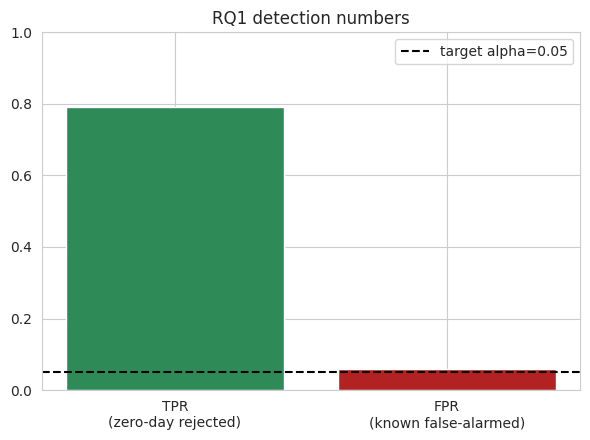

In [37]:
zday_out = run_batched_safely(qsnet_infer_batch, A_zeroday, theta_final, prototypes_final, q_final, forward_circuit,
                               p=NOISE_P, L_phi=L_PHI_ANALYTIC, Cf=DEFAULT_CF, zero_day=ZERO_DAY, device=DEVICE,
                               batch_size=QBATCH, min_batch=1, label="qsnet_infer_batch[zeroday]")
labels_zday_final = zday_out[0]

TPR_zeroday = float(np.mean(labels_zday_final == ZERO_DAY))
FPR_known   = float(np.mean(labels_test_final == ZERO_DAY))
accepted_known = labels_test_final != ZERO_DAY
class_acc_known = float(np.mean(labels_test_final[accepted_known] == y_test[accepted_known]))

print(f"Zero-day detection TPR (rejected):         {TPR_zeroday:.3f}")
print(f"Known false-alarm rate (wrongly rejected):  {FPR_known:.3f}  (should track alpha={DEFAULT_ALPHA})")
print(f"Classification accuracy among accepted known samples: {class_acc_known:.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["TPR\n(zero-day rejected)", "FPR\n(known false-alarmed)"], [TPR_zeroday, FPR_known], color=["seagreen", "firebrick"])
ax.axhline(DEFAULT_ALPHA, color="black", linestyle="--", label=f"target alpha={DEFAULT_ALPHA}")
ax.set_ylim(0, 1); ax.set_title("RQ1 detection numbers"); ax.legend()
plt.tight_layout(); plt.show()
safe_empty_cache()

## Day 25 -- RQ3 disentanglement experiment

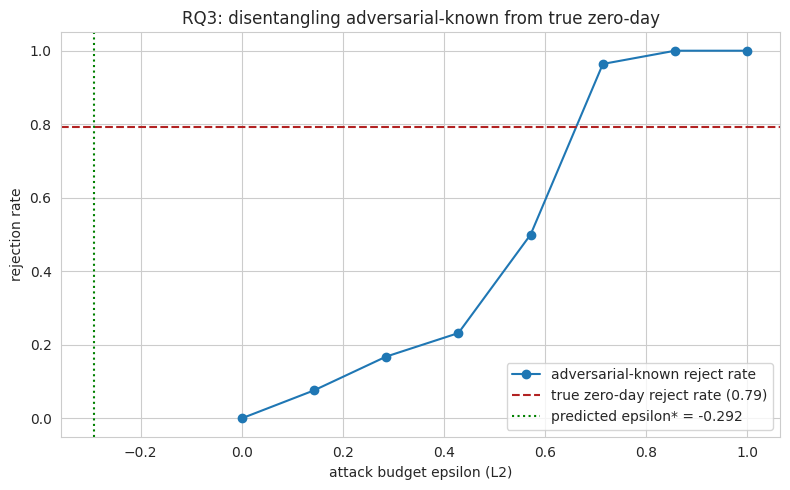

Disentanglement holds while the adversarial-known curve stays low and clearly below the true
zero-day reference line -- expected up to roughly epsilon* (marked in green).


In [38]:
eps_l2_sweep = np.linspace(0.0, max(EPS_STAR_GLOBAL * 2.5, 1.0), 8)     # reduced resolution
eps_inf_sweep = [l2_to_linf_budget(e, d=N_QUBITS) for e in eps_l2_sweep]

A_known_rq3 = A_test[accepted_known][:250]

rq3_rows = []
for e_l2, e_inf in zip(eps_l2_sweep, eps_inf_sweep):
    if e_inf == 0.0:
        X_adv = to_torch_batch_x(A_known_rq3, device=DEVICE)
    else:
        X_adv = run_batched_safely(fgsm_attack_nonconformity, A_known_rq3, theta_final, prototypes_final,
                                    forward_circuit, eps=e_inf, device=DEVICE, x_min=0.0, x_max=float(np.pi),
                                    proto_stack=proto_stack_main, batch_size=QBATCH, min_batch=1,
                                    label=f"rq3_fgsm[eps={e_inf:.3f}]")
        if X_adv is None:
            rq3_rows.append({"eps_l2": e_l2, "adv_known_reject_rate": np.nan})
            continue
    infer_out = run_batched_safely(qsnet_infer_batch, X_adv.cpu().numpy(), theta_final, prototypes_final, q_final,
                                    forward_circuit, p=NOISE_P, L_phi=L_PHI_ANALYTIC, Cf=DEFAULT_CF,
                                    zero_day=ZERO_DAY, device=DEVICE, batch_size=QBATCH, min_batch=1,
                                    label=f"rq3_infer[eps={e_inf:.3f}]")
    reject_rate = float(np.mean(infer_out[0] == ZERO_DAY)) if infer_out is not None else np.nan
    rq3_rows.append({"eps_l2": e_l2, "adv_known_reject_rate": reject_rate})
    safe_empty_cache()

df_rq3 = pd.DataFrame(rq3_rows).dropna(subset=["adv_known_reject_rate"])

if not df_rq3.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df_rq3["eps_l2"], df_rq3["adv_known_reject_rate"], marker="o", label="adversarial-known reject rate")
    ax.axhline(TPR_zeroday, color="firebrick", linestyle="--", label=f"true zero-day reject rate ({TPR_zeroday:.2f})")
    ax.axvline(EPS_STAR_GLOBAL, color="green", linestyle=":", label=f"predicted epsilon* = {EPS_STAR_GLOBAL:.3f}")
    ax.set_xlabel("attack budget epsilon (L2)"); ax.set_ylabel("rejection rate")
    ax.set_title("RQ3: disentangling adversarial-known from true zero-day"); ax.legend()
    plt.tight_layout(); plt.show()
    print("Disentanglement holds while the adversarial-known curve stays low and clearly below the true")
    print("zero-day reference line -- expected up to roughly epsilon* (marked in green).")
else:
    print("RQ3 sweep produced no usable points (all skipped under memory pressure).")

## Save theory-validation results
(defensive to any upstream steps that were skipped under memory pressure)

In [39]:
theory_validation = {
    "fidelity_convention_check": check,
    "prop1_max_residual": max_resid,
    "lipschitz_analytic": L_PHI_ANALYTIC,
    "lipschitz_diagnostic": {n: {k: v for k, v in r.items() if k != "ratios"} for n, r in lipschitz_diag.items()},
    "certified_radius": {"mean": float(certified_radii_correct.mean()), "median": float(np.median(certified_radii_correct)),
                          "min": float(certified_radii_correct.min()), "max": float(certified_radii_correct.max())},
    "F_in": F_IN, "F_out": F_OUT, "delta_strict": delta_strict, "epsilon_star_strict": eps_star_strict,
    "F_out_beta": F_out_beta, "delta_beta": delta_beta, "epsilon_beta": eps_beta,
    "day19_acceptance_curve": df_day19.to_dict(orient="records"),
    "empirical_breakpoint_l2": empirical_breakpoint_l2,
    "H3_holds": bool(h3_holds),
    "day20_p_sweep": df_day20.to_dict(orient="records"),
    "day21_per_dataset": df_day21.to_dict(orient="records"),
    "F_in_global": float(F_IN_GLOBAL), "epsilon_star_global": EPS_STAR_GLOBAL,
    "RQ1_detection": {"TPR_zeroday": TPR_zeroday, "FPR_known": FPR_known, "class_acc_known": class_acc_known},
    "RQ3_disentanglement": df_rq3.to_dict(orient="records"),
}

log_dir = "/kaggle/working/logs"
os.makedirs(log_dir, exist_ok=True)
with open(os.path.join(log_dir, "theory_validation_full.json"), "w") as f:
    json.dump(to_jsonable(theory_validation), f, indent=2)

print("Saved -> /kaggle/working/logs/theory_validation_full.json")
print("Saved -> /kaggle/working/checkpoints/robustness_interface_day21.pt")
gpu_mem_report("final")

Saved -> /kaggle/working/logs/theory_validation_full.json
Saved -> /kaggle/working/checkpoints/robustness_interface_day21.pt
[mem final] GPU0 0.28/15.64 GB used  |  GPU1 0.20/15.64 GB used
